Images downloaded successfully from Unsplash.
Source image size: (1500, 1000)
Reference image size: (667, 1000)


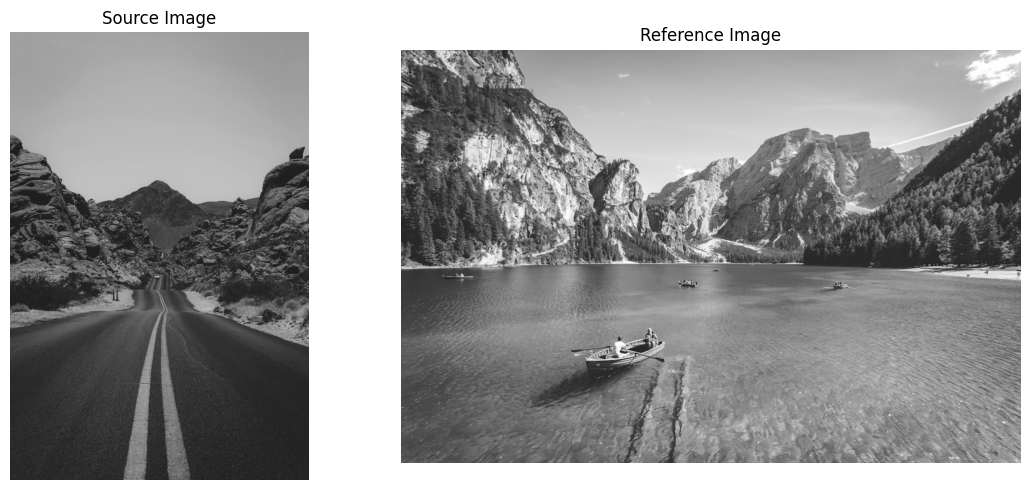

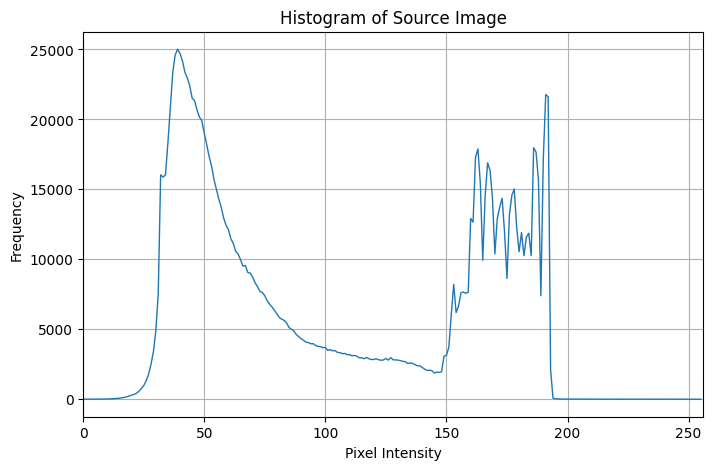

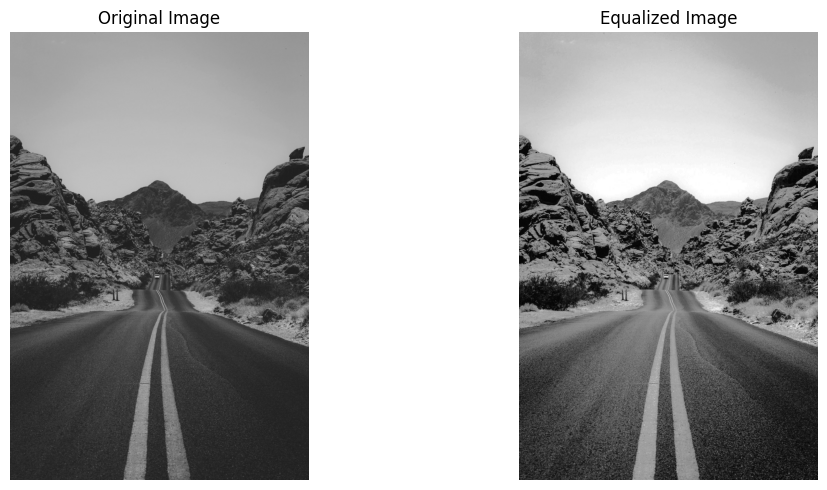

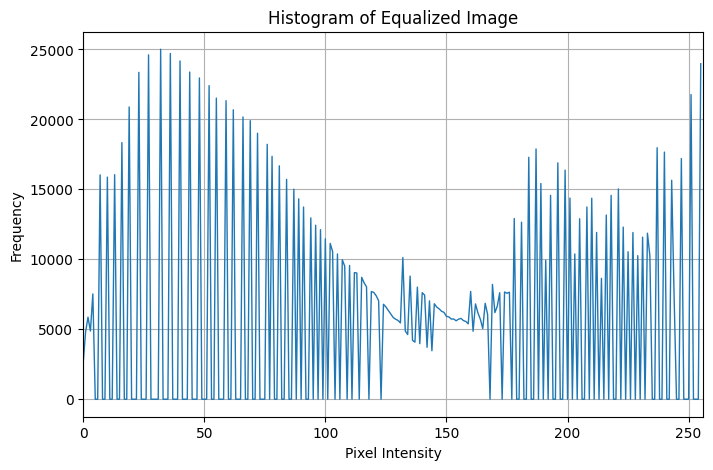

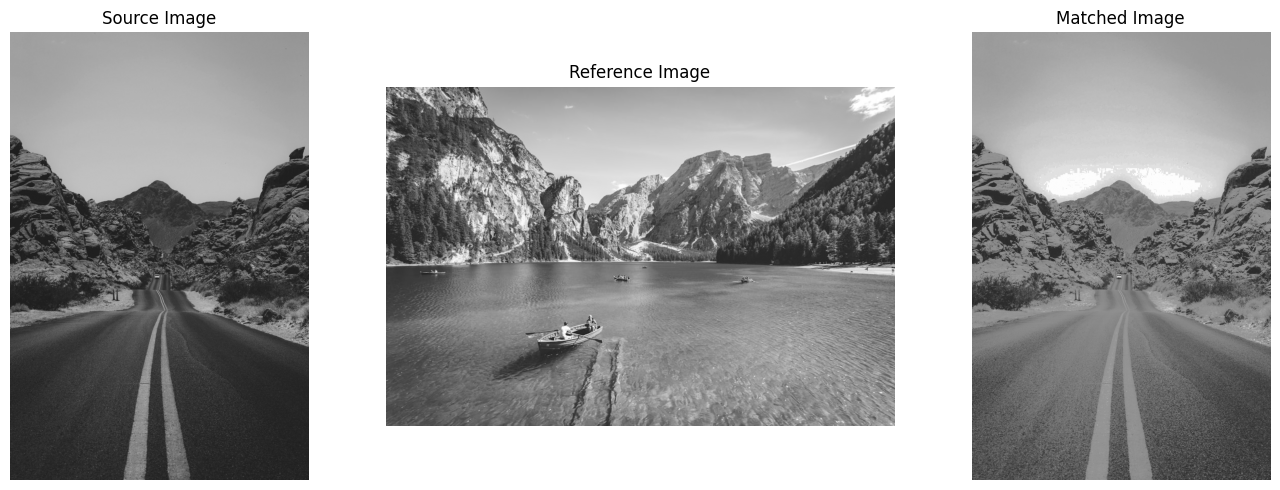

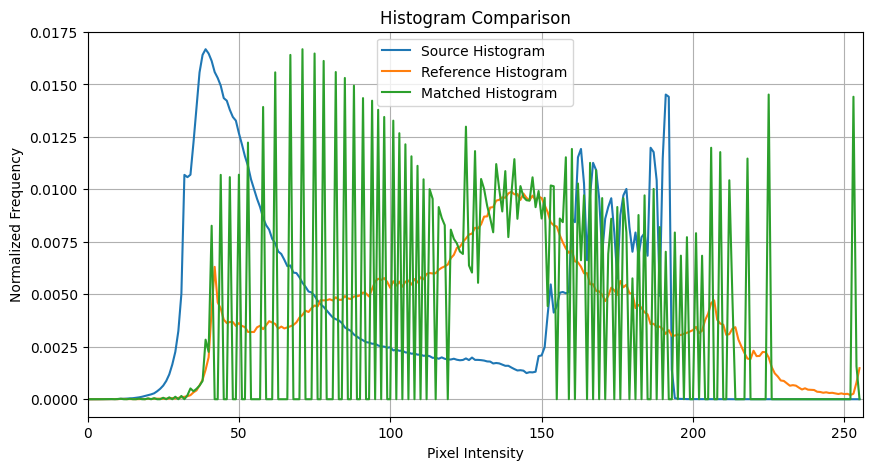

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import requests
from PIL import Image
from io import BytesIO


# ============================================================
# PART 1: DOWNLOAD IMAGES FROM UNSPLASH
# ============================================================

# Source image
source_url = (
    "https://images.unsplash.com/"
    "photo-1500530855697-b586d89ba3ee"
    "?auto=format&fit=crop&w=1000&q=80"
)

# Reference image
reference_url = (
    "https://images.unsplash.com/"
    "photo-1501785888041-af3ef285b470"
    "?auto=format&fit=crop&w=1000&q=80"
)


# -------------------- DOWNLOAD SOURCE IMAGE --------------------

source_response = requests.get(source_url)

if source_response.status_code != 200:
    raise Exception("Could not download source image.")

source_pil = Image.open(
    BytesIO(source_response.content)
).convert("RGB")

# Convert RGB to OpenCV format
source_rgb = np.array(source_pil)
source_image = cv2.cvtColor(
    source_rgb,
    cv2.COLOR_RGB2GRAY
)


# -------------------- DOWNLOAD REFERENCE IMAGE --------------------

reference_response = requests.get(reference_url)

if reference_response.status_code != 200:
    raise Exception("Could not download reference image.")

reference_pil = Image.open(
    BytesIO(reference_response.content)
).convert("RGB")

# Convert RGB to OpenCV format
reference_rgb = np.array(reference_pil)
reference_image = cv2.cvtColor(
    reference_rgb,
    cv2.COLOR_RGB2GRAY
)


print("Images downloaded successfully from Unsplash.")
print("Source image size:", source_image.shape)
print("Reference image size:", reference_image.shape)


# ============================================================
# PART 2: DISPLAY SOURCE AND REFERENCE IMAGES
# ============================================================

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(source_image, cmap="gray")
plt.title("Source Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(reference_image, cmap="gray")
plt.title("Reference Image")
plt.axis("off")

plt.tight_layout()
plt.show()


# ============================================================
# PART 3: GENERATE HISTOGRAM
# ============================================================

# Calculate histogram of source image
source_histogram = cv2.calcHist(
    [source_image],
    [0],
    None,
    [256],
    [0, 256]
)

# Plot histogram
plt.figure(figsize=(8, 5))

plt.plot(
    source_histogram,
    linewidth=1
)

plt.title("Histogram of Source Image")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.xlim([0, 256])
plt.grid(True)

plt.show()


# ============================================================
# PART 4: HISTOGRAM EQUALIZATION
# ============================================================

# Perform histogram equalization
equalized_image = cv2.equalizeHist(
    source_image
)


# Display original and equalized images
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(
    source_image,
    cmap="gray"
)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(
    equalized_image,
    cmap="gray"
)
plt.title("Equalized Image")
plt.axis("off")

plt.tight_layout()
plt.show()


# ============================================================
# PART 5: HISTOGRAM OF EQUALIZED IMAGE
# ============================================================

equalized_histogram = cv2.calcHist(
    [equalized_image],
    [0],
    None,
    [256],
    [0, 256]
)


# Plot equalized histogram
plt.figure(figsize=(8, 5))

plt.plot(
    equalized_histogram,
    linewidth=1
)

plt.title("Histogram of Equalized Image")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.xlim([0, 256])
plt.grid(True)

plt.show()


# ============================================================
# PART 6: HISTOGRAM MATCHING
# ============================================================

# Calculate source histogram
source_hist = cv2.calcHist(
    [source_image],
    [0],
    None,
    [256],
    [0, 256]
).flatten()


# Calculate reference histogram
reference_hist = cv2.calcHist(
    [reference_image],
    [0],
    None,
    [256],
    [0, 256]
).flatten()


# -------------------- NORMALIZE HISTOGRAMS --------------------

source_hist = source_hist / source_hist.sum()

reference_hist = reference_hist / reference_hist.sum()


# -------------------- CALCULATE CDF --------------------

source_cdf = np.cumsum(source_hist)

reference_cdf = np.cumsum(reference_hist)


# -------------------- CREATE INTENSITY MAPPING --------------------

intensity_values = np.arange(256)

mapping = np.interp(
    source_cdf,
    reference_cdf,
    intensity_values
)


# -------------------- APPLY MAPPING --------------------

matched_image = mapping[
    source_image
]


# Convert to uint8
matched_image = np.clip(
    matched_image,
    0,
    255
).astype(np.uint8)


# ============================================================
# PART 7: DISPLAY HISTOGRAM MATCHING RESULTS
# ============================================================

plt.figure(figsize=(15, 5))


# Source image
plt.subplot(1, 3, 1)

plt.imshow(
    source_image,
    cmap="gray"
)

plt.title("Source Image")
plt.axis("off")


# Reference image
plt.subplot(1, 3, 2)

plt.imshow(
    reference_image,
    cmap="gray"
)

plt.title("Reference Image")
plt.axis("off")


# Matched image
plt.subplot(1, 3, 3)

plt.imshow(
    matched_image,
    cmap="gray"
)

plt.title("Matched Image")
plt.axis("off")


plt.tight_layout()
plt.show()


# ============================================================
# PART 8: COMPARE HISTOGRAMS
# ============================================================

# Histogram of matched image
matched_histogram = cv2.calcHist(
    [matched_image],
    [0],
    None,
    [256],
    [0, 256]
).flatten()


# Normalize matched histogram
matched_histogram = (
    matched_histogram /
    matched_histogram.sum()
)


# Plot comparison
plt.figure(figsize=(10, 5))

plt.plot(
    source_hist,
    label="Source Histogram"
)

plt.plot(
    reference_hist,
    label="Reference Histogram"
)

plt.plot(
    matched_histogram,
    label="Matched Histogram"
)

plt.title("Histogram Comparison")
plt.xlabel("Pixel Intensity")
plt.ylabel("Normalized Frequency")
plt.xlim([0, 256])
plt.grid(True)
plt.legend()

plt.show()


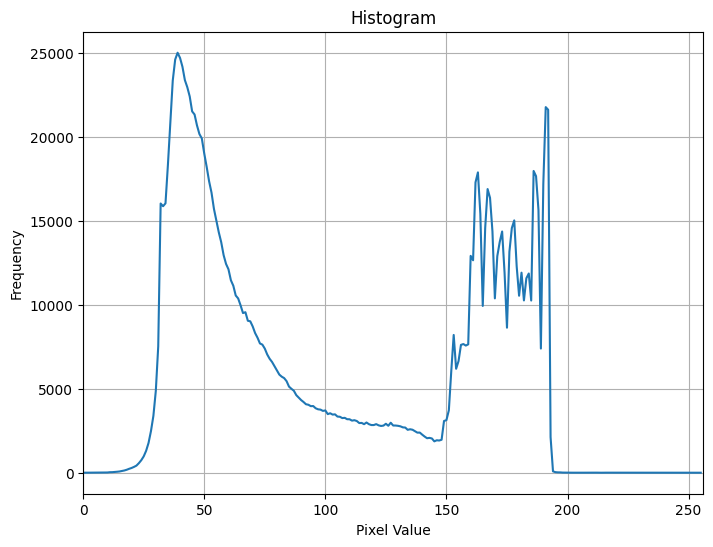

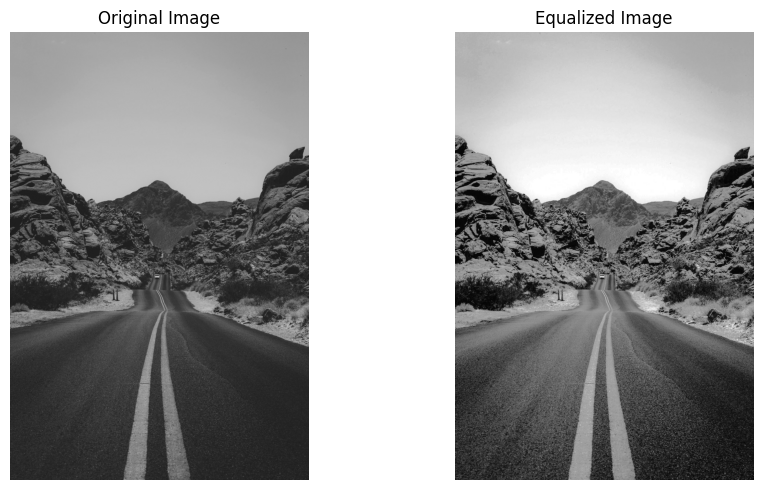

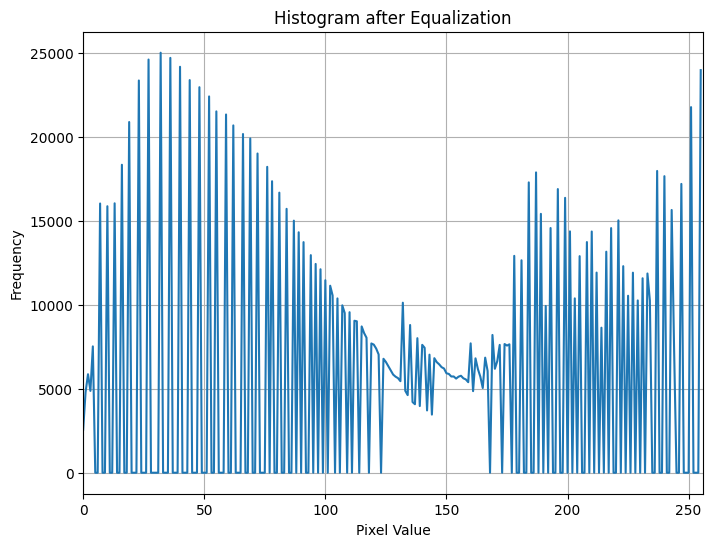

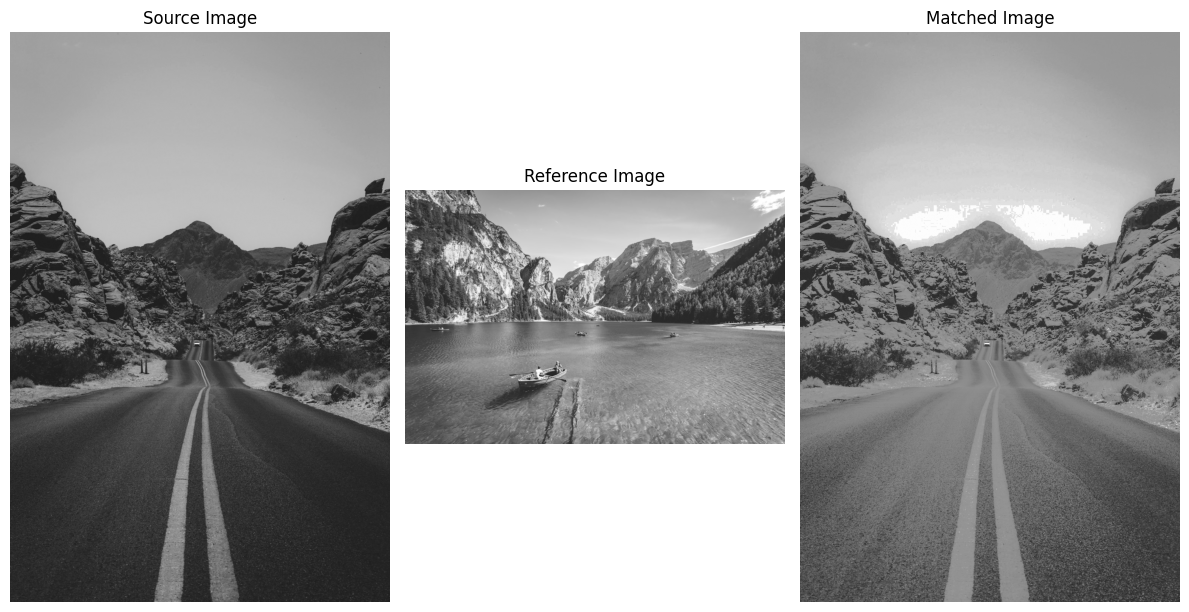

In [5]:
# Import required libraries
import cv2
import numpy as np
from matplotlib import pyplot as plt
import requests
from PIL import Image
from io import BytesIO


# ==========================================================
# Load the image
# ==========================================================

image_url = "https://images.unsplash.com/photo-1500530855697-b586d89ba3ee?auto=format&fit=crop&w=1000&q=80"

response = requests.get(image_url)

image = Image.open(BytesIO(response.content)).convert("L")
image = np.array(image)

# Calculate the histogram
histogram = cv2.calcHist([image], [0], None, [256], [0, 256])

# Plot the histogram
plt.figure(figsize=(8, 6))
plt.title('Histogram')
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')
plt.plot(histogram)
plt.xlim([0, 256])
plt.grid(True)
plt.show()


# ==========================================================
# Perform histogram equalization
# ==========================================================

equalized_image = cv2.equalizeHist(image)

# Display the original and equalized images
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title('Original Image')
plt.imshow(image, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title('Equalized Image')
plt.imshow(equalized_image, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()


# ==========================================================
# Calculate the histogram of equalized image
# ==========================================================

histogram = cv2.calcHist(
    [equalized_image],
    [0],
    None,
    [256],
    [0, 256]
)

# Plot the histogram
plt.figure(figsize=(8, 6))
plt.title('Histogram after Equalization')
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')
plt.plot(histogram)
plt.xlim([0, 256])
plt.grid(True)
plt.show()


# ==========================================================
# Histogram Matching
# ==========================================================

# Load the source and reference images

source_url = "https://images.unsplash.com/photo-1500530855697-b586d89ba3ee?auto=format&fit=crop&w=1000&q=80"

reference_url = "https://images.unsplash.com/photo-1501785888041-af3ef285b470?auto=format&fit=crop&w=1000&q=80"


# Download source image
source_response = requests.get(source_url)

source_image = Image.open(
    BytesIO(source_response.content)
).convert("L")

source_image = np.array(source_image)


# Download reference image
reference_response = requests.get(reference_url)

reference_image = Image.open(
    BytesIO(reference_response.content)
).convert("L")

reference_image = np.array(reference_image)


# Calculate histograms for the source and reference images
source_hist = cv2.calcHist(
    [source_image],
    [0],
    None,
    [256],
    [0, 256]
)

reference_hist = cv2.calcHist(
    [reference_image],
    [0],
    None,
    [256],
    [0, 256]
)


# Normalize histograms to have sum equal to 1
source_hist /= source_hist.sum()
reference_hist /= reference_hist.sum()


# Calculate cumulative distribution functions (CDF) for histograms
source_cdf = source_hist.cumsum()
reference_cdf = reference_hist.cumsum()


# Perform histogram matching by mapping source CDF to reference CDF
mapping = np.interp(
    source_cdf,
    reference_cdf,
    range(256)
)

matched_image = mapping[source_image]


# Convert to uint8 data type
matched_image = matched_image.astype(np.uint8)


# Display the images using Matplotlib
plt.figure(figsize=(12, 6))

plt.subplot(131)
plt.title('Source Image')
plt.imshow(source_image, cmap='gray')
plt.axis('off')

plt.subplot(132)
plt.title('Reference Image')
plt.imshow(reference_image, cmap='gray')
plt.axis('off')

plt.subplot(133)
plt.title('Matched Image')
plt.imshow(matched_image, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()